In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

In [22]:
df=pd.read_csv('kaggle-preprocessed.csv')

In [23]:
df.head()

,Unnamed: 0,Dataset_name,Author_name,Author_id,No_of_files,size,Type_of_file,Upvotes,Medals,Usability,Date,Day,Time,Dataset_link
0,0,Hotel Reservations Dataset,Ahsan Raza,https://www.kaggle.com/ahsan81,1,491 kB,CSV,315,Silver,10.0,01-04-2023,Wed,18:20:31,https://www.kaggle.com/datasets/ahsan81/hotel-...
1,2,Most Subscribed 1000 Youtube Channels,Mrityunjay Pathak,https://www.kaggle.com/themrityunjaypathak,1,29 kB,CSV,76,Bronze,10.0,1/21/2023,Sat,20:12:05,https://www.kaggle.com/datasets/themrityunjayp...
2,3,Olympics 124 years Dataset(till 2020),Nitish Sharma01,https://www.kaggle.com/nitishsharma01,3,5 MB,CSV,30,Bronze,10.0,02-01-2023,Wed,14:30:49,https://www.kaggle.com/datasets/nitishsharma01...
3,4,Medical Student Mental Health,The Devastator,https://www.kaggle.com/thedevastator,2,19 kB,CSV,37,Bronze,10.0,1/25/2023,Wed,06:30:14,https://www.kaggle.com/datasets/thedevastator/...
4,5,Latest Netflix TV shows and movies,Senapati Rajesh,https://www.kaggle.com/senapatirajesh,1,1 MB,CSV,94,Bronze,9.4,1/14/2023,Sat,22:33:12,https://www.kaggle.com/datasets/senapatirajesh...


In [24]:
df['Type_of_file'].value_counts()

Type_of_file
CSV                   5772
other                 2007
other, CSV             528
CSV, other             427
other, JSON            153
JSON                    73
JSON, CSV               42
other, CSV, JSON        29
CSV, JSON               27
other, JSON, CSV        26
SQLITE                  19
JSON, other             15
CSV, other, JSON        10
JSON, other, CSV         6
SQLITE, CSV              6
CSV, JSON, other         5
JSON, CSV, other         5
CSV, SQLITE              1
CSV, SQLITE, other       1
SQLITE, other            1
other, SQLITE, CSV       1
SQLITE, CSV, other       1
SQLITE, other, CSV       1
Name: count, dtype: int64

In [25]:
df['size'].value_counts().sum()

np.int64(9158)

In [26]:
X=df.drop(['Dataset_name','Author_name','Author_id','Date','Day','Time','Dataset_link','size'], axis=1)

In [27]:

X=X.drop('Type_of_file', axis=1).join(pd.get_dummies(X['Type_of_file'], drop_first=True).astype(int))
X=X.drop('Medals', axis=1).join(pd.get_dummies(X['Medals'], drop_first=True).astype(int))

In [28]:
def convert_to_mb(size):
    size = size.strip().upper()
    
    if "GB" in size:
        return float(size.replace("GB", "").strip()) * 1024
    elif "MB" in size:
        return float(size.replace("MB", "").strip())
    elif "KB" in size:
        return float(size.replace("KB", "").strip()) / 1024
    elif "B" in size:
        return float(size.replace("B", "").strip()) / (1024 ** 2)
    else:
        return None
    
df['file_size_mb'] = df['size'].apply(convert_to_mb)

In [29]:
X['file_size_mb'] = df['file_size_mb']

In [30]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9158 entries, 0 to 9157
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          9158 non-null   int64  
 1   No_of_files         9158 non-null   int64  
 2   Upvotes             9158 non-null   int64  
 3   Usability           9158 non-null   float64
 4   CSV, JSON           9158 non-null   int64  
 5   CSV, JSON, other    9158 non-null   int64  
 6   CSV, SQLITE         9158 non-null   int64  
 7   CSV, SQLITE, other  9158 non-null   int64  
 8   CSV, other          9158 non-null   int64  
 9   CSV, other, JSON    9158 non-null   int64  
 10  JSON                9158 non-null   int64  
 11  JSON, CSV           9158 non-null   int64  
 12  JSON, CSV, other    9158 non-null   int64  
 13  JSON, other         9158 non-null   int64  
 14  JSON, other, CSV    9158 non-null   int64  
 15  SQLITE              9158 non-null   int64  
 16  SQLITE

In [31]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9158 entries, 0 to 9157
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          9158 non-null   int64  
 1   No_of_files         9158 non-null   int64  
 2   Upvotes             9158 non-null   int64  
 3   Usability           9158 non-null   float64
 4   CSV, JSON           9158 non-null   int64  
 5   CSV, JSON, other    9158 non-null   int64  
 6   CSV, SQLITE         9158 non-null   int64  
 7   CSV, SQLITE, other  9158 non-null   int64  
 8   CSV, other          9158 non-null   int64  
 9   CSV, other, JSON    9158 non-null   int64  
 10  JSON                9158 non-null   int64  
 11  JSON, CSV           9158 non-null   int64  
 12  JSON, CSV, other    9158 non-null   int64  
 13  JSON, other         9158 non-null   int64  
 14  JSON, other, CSV    9158 non-null   int64  
 15  SQLITE              9158 non-null   int64  
 16  SQLITE

In [38]:
from sklearn.metrics import silhouette_score

model= KMeans(n_clusters=4, random_state=42)

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
model.fit(X_train)
y_pred = model.predict(X_test)
print(y_pred)

print(silhouette_score(X_test, y_pred))

[0 0 0 ... 0 0 0]
0.9668427904156853


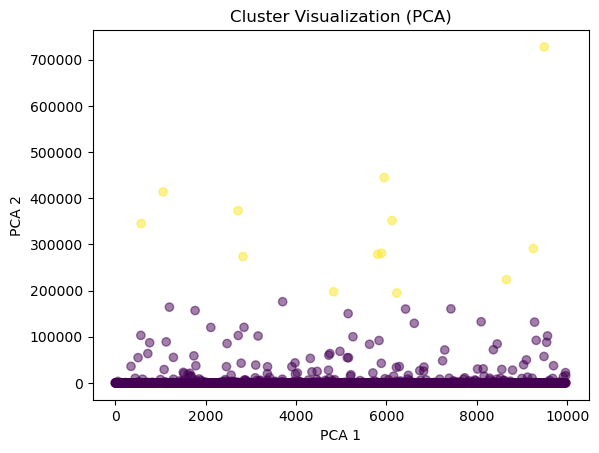

In [40]:

plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_pred, alpha=0.5, cmap='viridis')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Cluster Visualization (PCA)")
plt.show()


Silhouette Score: 0.25688839728806456


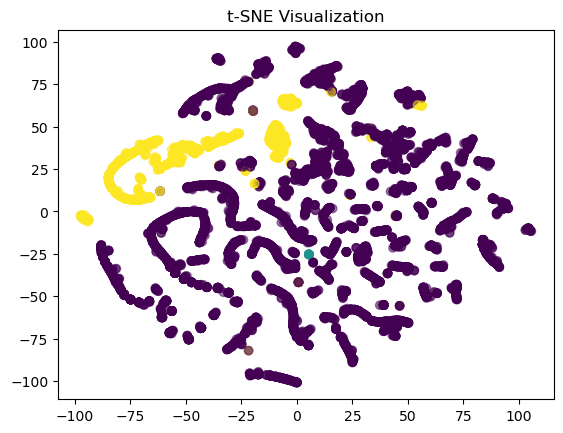

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

# Load data
df = pd.read_csv("kaggle-preprocessed.csv")

# Convert size to MB
def convert_to_mb(size):
    size = str(size).strip().upper()

    if "GB" in size:
        return float(size.replace("GB", "").strip()) * 1024
    elif "MB" in size:
        return float(size.replace("MB", "").strip())
    elif "KB" in size:
        return float(size.replace("KB", "").strip()) / 1024
    elif "B" in size:
        return float(size.replace("B", "").strip()) / (1024 ** 2)
    else:
        return np.nan

df["file_size_mb"] = df["size"].apply(convert_to_mb)

# Drop unnecessary columns
X = df.drop([
    "Dataset_name", "Author_name", "Author_id", "Date",
    "Day", "Time", "Dataset_link", "size"
], axis=1)

# Drop index-like column if useless
if "Unnamed: 0" in X.columns:
    X = X.drop("Unnamed: 0", axis=1)

# One-hot encode categorical columns
X = X.drop("Type_of_file", axis=1).join(
    pd.get_dummies(X["Type_of_file"], drop_first=True).astype(int)
)

X = X.drop("Medals", axis=1).join(
    pd.get_dummies(X["Medals"], drop_first=True).astype(int)
)

# Fill missing values if any
X = X.fillna(0)

# Scale + KMeans
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=3, random_state=42))
])

pipeline.fit(X)

# Cluster labels
labels = pipeline.named_steps["kmeans"].labels_

# Silhouette score on scaled data
X_scaled = pipeline.named_steps["scaler"].transform(X)
score = silhouette_score(X_scaled, labels)

print("Silhouette Score:", score)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Cluster centers in PCA space
centers_scaled = pipeline.named_steps["kmeans"].cluster_centers_
centers_pca = pca.transform(centers_scaled)

# Plot
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, alpha=0.5)
plt.title("t-SNE Visualization")
plt.show()